# T11 Controlled Feature / Representation Optimization

T11 tests the two feature choices deferred by T08 without changing the four T10-tuned model configurations. Feature variants are selected independently for each model using Train-only chronological CV PR-AUC. Outer Validation is evaluated only after selection; Test remains untouched. No threshold optimization, resampling, broad tuning, or final-model selection is performed.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import load_weather_data, chronological_train_validation_test_split
from fdm_rainfall.feature_optimization import (
    T10_TUNED_PARAMETERS, VARIANT_ORDER, compare_t09_t10_t11,
    feature_variant_definitions, fit_selected_variants_on_validation,
    prepare_all_variant_folds, run_feature_experiment,
    save_feature_optimization_figures, select_feature_variants,
    summarize_feature_experiment,
)
from fdm_rainfall.modeling import MODEL_NAMES
from fdm_rainfall.tuning import cv_fold_boundary_table, date_aware_expanding_window_splits

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'feature_optimization'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_SHA256 = '573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014'
pd.set_option('display.max_columns', 60)
pd.set_option('display.precision', 6)

## Data boundary and controlled variants

The unchanged chronological split contains 99,546 Train, 21,342 Validation, and 21,305 reserved Test rows. The four variants are V0 default; V1 default plus Year; V2 default with `Rainfall_log1p` replacing raw Rainfall; and V3 with both Year and the replacement. Month remains cyclical. ClimateZone stays deferred because no authoritative mapping exists.

In [2]:
raw_checksum = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
assert raw_checksum == EXPECTED_SHA256
raw = load_weather_data(DATA_PATH)
split = chronological_train_validation_test_split(raw)
assert [len(split.train), len(split.validation), len(split.test)] == [99_546, 21_342, 21_305]
folds = date_aware_expanding_window_splits(split.train['Date'], n_splits=3)
fold_boundaries = cv_fold_boundary_table(split.train['Date'], folds)
assert fold_boundaries['Strict chronology'].all()
assert (fold_boundaries[['Row overlap', 'Date overlap']] == 0).all().all()
fold_boundaries.to_csv(TABLE_DIR / '11_cv_fold_boundaries.csv', index=False)
display(split.summary)
display(fold_boundaries)

,Split,First date,Last date,Rows,Percentage of labelled rows,Unique dates,Locations,RainTomorrow No count,RainTomorrow Yes count,Yes percentage,Missing target count
0,Train,2007-11-01,2015-01-12,99546,70.007666,2541,49,77087,22459,22.561429,0
1,Validation,2015-01-13,2016-04-08,21342,15.009178,452,48,16990,4352,20.391716,0
2,Test,2016-04-09,2017-06-25,21305,14.983157,443,49,16239,5066,23.778456,0


,Fold,Train first date,Train last date,Validation first date,Validation last date,Train rows,Validation rows,Train unique dates,Validation unique dates,Row overlap,Date overlap,Strict chronology
0,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,636,635,0,0,True
1,2,2007-11-01,2011-05-24,2011-05-25,2013-04-17,40484,28720,1271,635,0,0,True
2,3,2007-11-01,2013-04-17,2013-04-18,2015-01-12,69204,30342,1906,635,0,0,True


## Fixed models, feature definitions, and experiment size

T11 reuses the exact T10 hyperparameters and does not retune them. Four models times four variants times three folds gives 48 model fits. Logistic Regression uses scaled matrices; Decision Tree, Random Forest, and Gradient Boosting use unscaled matrices.

In [3]:
variant_table = pd.DataFrame([
    {'Variant': name, 'Add Year': definition.add_year,
     'Replace Rainfall with log1p': definition.log_rainfall_replace}
    for name, definition in feature_variant_definitions().items()
])
model_table = pd.DataFrame([
    {'Model': name, 'Fixed T10 parameters': json.dumps(T10_TUNED_PARAMETERS[name], sort_keys=True),
     'Representation route': 'scaled' if name == 'Logistic Regression' else 'unscaled'}
    for name in MODEL_NAMES
])
variant_table.to_csv(TABLE_DIR / '11_feature_variants.csv', index=False)
model_table.to_csv(TABLE_DIR / '11_fixed_model_configurations.csv', index=False)
display(variant_table)
display(model_table)
print('Planned CV fits:', 4 * 4 * 3)

,Variant,Add Year,Replace Rainfall with log1p
0,V0_DEFAULT,False,False
1,V1_ADD_YEAR,True,False
2,V2_LOG_RAINFALL_REPLACE,False,True
3,V3_YEAR_AND_LOG_RAINFALL,True,True


,Model,Fixed T10 parameters,Representation route
0,Logistic Regression,"{""C"": 0.1, ""class_weight"": null}",scaled
1,Decision Tree,"{""class_weight"": ""balanced"", ""criterion"": ""gin...",unscaled
2,Random Forest,"{""class_weight"": null, ""max_depth"": 20, ""max_f...",unscaled
3,Gradient Boosting,"{""learning_rate"": 0.1, ""max_depth"": 3, ""min_sa...",unscaled


Planned CV fits: 48


## Leakage-safe fold preprocessing

For every variant and fold, raw fold Train is engineered first, then a fresh preprocessor learns numerical medians, Location medians, fallbacks, categories, and scaling statistics from fold Train only. Fold Validation is transform-only. Safely prepared matrices may be reused across the fixed model families because preprocessing is model-parameter independent.

In [4]:
preparation_start = perf_counter()
prepared = prepare_all_variant_folds(split.train, folds)
preparation_seconds = perf_counter() - preparation_start
for variant in VARIANT_ORDER:
    for route in ('scaled', 'unscaled'):
        for definition, prepared_fold in zip(folds, prepared[variant][route], strict=True):
            assert prepared_fold.preprocessor.fit_row_count_ == len(definition.train_positions)
            assert prepared_fold.dates_train.max() < prepared_fold.dates_validation.min()
            assert prepared_fold.X_train.shape[1] == prepared_fold.X_validation.shape[1]
            assert np.isfinite(prepared_fold.X_train.to_numpy()).all()
            assert np.isfinite(prepared_fold.X_validation.to_numpy()).all()
print(f'Prepared 24 fold/variant representations in {preparation_seconds:.3f} seconds')

Prepared 24 fold/variant representations in 9.712 seconds


## Train-only feature experiment

Each fixed T10 model is evaluated on all four representations in all three folds. Average Precision / PR-AUC is the sole performance selection criterion. ROC-AUC, balanced accuracy, precision, recall, and F1 are descriptive only.

In [5]:
experiment = run_feature_experiment(prepared)
assert len(experiment.fold_results) == 48
experiment.fold_results.to_csv(TABLE_DIR / '11_cv_fold_results.csv', index=False)
experiment.runtime_summary.to_csv(TABLE_DIR / '11_model_variant_runtimes.csv', index=False)
display(experiment.fold_results.head(12))
display(experiment.runtime_summary)

,Model,Variant,Fold,Train first date,Train last date,Validation first date,Validation last date,Train rows,Validation rows,Processed feature count,Runtime seconds,PR-AUC,ROC-AUC,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes)
0,Logistic Regression,V0_DEFAULT,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,86,0.119922,0.710627,0.866765,0.732181,0.733705,0.523396,0.610958
1,Logistic Regression,V0_DEFAULT,2,2007-11-01,2011-05-24,2011-05-25,2013-04-17,40484,28720,86,0.286516,0.708928,0.873332,0.723286,0.745999,0.496727,0.596363
2,Logistic Regression,V0_DEFAULT,3,2007-11-01,2013-04-17,2013-04-18,2015-01-12,69204,30342,89,0.512655,0.701541,0.875302,0.740407,0.708509,0.541960,0.614143
3,Logistic Regression,V1_ADD_YEAR,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,87,0.115039,0.707420,0.864913,0.692190,0.797525,0.417304,0.547913
4,Logistic Regression,V1_ADD_YEAR,2,2007-11-01,2011-05-24,2011-05-25,2013-04-17,40484,28720,87,0.328019,0.708847,0.873305,0.725286,0.739539,0.503121,0.598840
5,Logistic Regression,V1_ADD_YEAR,3,2007-11-01,2013-04-17,2013-04-18,2015-01-12,69204,30342,90,0.534671,0.701537,0.875341,0.746615,0.697311,0.559877,0.621082
6,Logistic Regression,V2_LOG_RAINFALL_REPLACE,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,86,0.114710,0.711772,0.867281,0.732773,0.735896,0.523985,0.612119
7,Logistic Regression,V2_LOG_RAINFALL_REPLACE,2,2007-11-01,2011-05-24,2011-05-25,2013-04-17,40484,28720,86,0.302552,0.711687,0.873970,0.725000,0.746536,0.500381,0.599162
8,Logistic Regression,V2_LOG_RAINFALL_REPLACE,3,2007-11-01,2013-04-17,2013-04-18,2015-01-12,69204,30342,89,0.420140,0.702166,0.875420,0.740909,0.709142,0.542879,0.614971
9,Logistic Regression,V3_YEAR_AND_LOG_RAINFALL,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,87,0.091281,0.708896,0.865529,0.695295,0.798061,0.423926,0.553719


,Model,Variant,CV folds,Runtime seconds
0,Logistic Regression,V0_DEFAULT,3,1.656110
1,Logistic Regression,V1_ADD_YEAR,3,1.731328
2,Logistic Regression,V2_LOG_RAINFALL_REPLACE,3,1.588394
3,Logistic Regression,V3_YEAR_AND_LOG_RAINFALL,3,1.527298
4,Decision Tree,V0_DEFAULT,3,2.177688
5,Decision Tree,V1_ADD_YEAR,3,2.079544
6,Decision Tree,V2_LOG_RAINFALL_REPLACE,3,1.971088
7,Decision Tree,V3_YEAR_AND_LOG_RAINFALL,3,2.018738
8,Random Forest,V0_DEFAULT,3,5.591511
9,Random Forest,V1_ADD_YEAR,3,5.626544


## Model-by-variant summary and Train-CV winners

Representations are selected independently per model by mean Train-CV PR-AUC descending. Exact PR-AUC ties use V0, V1, V2, V3 order only; no other performance metric can influence selection. Outer Validation has not been accessed by the selection function.

In [6]:
variant_summary = summarize_feature_experiment(experiment.fold_results)
winners = select_feature_variants(variant_summary)
variant_summary.to_csv(TABLE_DIR / '11_model_variant_summary.csv', index=False)
winners.to_csv(TABLE_DIR / '11_representation_winners.csv', index=False)
display(variant_summary)
display(winners)

,Model,Variant,CV folds,Processed features min,Processed features max,Runtime seconds,CV PR-AUC mean,CV PR-AUC std,CV ROC-AUC mean,CV ROC-AUC std,CV Balanced Accuracy mean,CV Balanced Accuracy std,CV Precision (Yes) mean,CV Precision (Yes) std,CV Recall (Yes) mean,CV Recall (Yes) std,CV F1 (Yes) mean,CV F1 (Yes) std
0,Logistic Regression,V0_DEFAULT,3,86,89,0.919094,0.707032,0.003944,0.871800,0.003650,0.731958,0.006992,0.729404,0.015605,0.520694,0.018565,0.607155,0.007741
1,Logistic Regression,V1_ADD_YEAR,3,87,90,0.977729,0.705935,0.003164,0.871186,0.004513,0.721364,0.022391,0.744792,0.041081,0.493434,0.058607,0.589279,0.030627
2,Logistic Regression,V2_LOG_RAINFALL_REPLACE,3,86,89,0.837402,0.708542,0.004509,0.872224,0.003545,0.732894,0.006495,0.730525,0.015732,0.522415,0.017385,0.608750,0.006880
3,Logistic Regression,V3_YEAR_AND_LOG_RAINFALL,3,87,90,0.860952,0.707561,0.003963,0.871683,0.004401,0.722470,0.020624,0.745301,0.041348,0.495686,0.054770,0.591441,0.027625
4,Decision Tree,V0_DEFAULT,3,86,89,1.466641,0.640795,0.015415,0.830150,0.013030,0.754032,0.013819,0.498403,0.007688,0.721195,0.018800,0.589375,0.010007
5,Decision Tree,V1_ADD_YEAR,3,87,90,1.393380,0.639196,0.014772,0.830027,0.012804,0.753847,0.014017,0.497231,0.007924,0.722019,0.021479,0.588762,0.009582
6,Decision Tree,V2_LOG_RAINFALL_REPLACE,3,86,89,1.283037,0.640794,0.015414,0.830147,0.013027,0.754032,0.013819,0.498403,0.007688,0.721195,0.018800,0.589375,0.010007
7,Decision Tree,V3_YEAR_AND_LOG_RAINFALL,3,87,90,1.352341,0.639195,0.014771,0.830024,0.012801,0.753847,0.014017,0.497231,0.007924,0.722019,0.021479,0.588762,0.009582
8,Random Forest,V0_DEFAULT,3,86,89,4.838302,0.722824,0.008788,0.877995,0.009579,0.720426,0.004773,0.770220,0.007278,0.483190,0.008670,0.593762,0.005881
9,Random Forest,V1_ADD_YEAR,3,87,90,4.875969,0.722548,0.007862,0.877895,0.008628,0.717707,0.003569,0.771728,0.010142,0.476899,0.006339,0.589432,0.004099


,Model,Selected feature variant,Mean CV PR-AUC,CV PR-AUC std,Difference versus V0 default,Tie-break required
0,Logistic Regression,V2_LOG_RAINFALL_REPLACE,0.708542,0.004509,0.001510,No
1,Decision Tree,V0_DEFAULT,0.640795,0.015415,0.000000,No
2,Random Forest,V0_DEFAULT,0.722824,0.008788,0.000000,No
3,Gradient Boosting,V1_ADD_YEAR,0.721401,0.002877,0.000224,No


## Complete-Train refit and one outer Validation evaluation

Only after Train-CV selection, each chosen representation is recreated from complete Train. Its preprocessor fits on complete Train only, Validation is transformed without refitting, and the fixed T10 model is evaluated once at its default classification threshold.

In [7]:
final = fit_selected_variants_on_validation(split.train, split.validation, winners)
final.comparison.to_csv(TABLE_DIR / '11_validation_metrics.csv', index=False)
final.comparison[['Model', 'Selected feature variant', 'TN', 'FP', 'FN', 'TP']].to_csv(
    TABLE_DIR / '11_validation_confusion_counts.csv', index=False
)
final.execution_times.to_csv(TABLE_DIR / '11_final_fit_times.csv', index=False)
display(final.comparison.style.format({column: '{:.6f}' for column in final.comparison.columns[3:10]}))

,Model,Selected feature variant,Processed feature count,Accuracy,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Logistic Regression,V2_LOG_RAINFALL_REPLACE,89,0.854278,0.704396,0.731199,0.451287,0.558113,0.870140,0.678523,16268,722,2388,1964
1,Decision Tree,V0_DEFAULT,89,0.800768,0.768042,0.508191,0.712776,0.593344,0.844848,0.635289,13988,3002,1250,3102
2,Random Forest,V0_DEFAULT,89,0.859385,0.700083,0.781341,0.431066,0.555605,0.883234,0.704679,16465,525,2476,1876
3,Gradient Boosting,V1_ADD_YEAR,90,0.856855,0.704647,0.749519,0.447610,0.560495,0.875246,0.692330,16339,651,2404,1948


## T09 versus T10 versus T11 Validation comparison

This comparison is descriptive. Validation did not choose the feature representations, and metric leaders are not a final-model decision.

In [8]:
t09 = pd.read_csv(TABLE_DIR / '09_validation_baseline_comparison.csv')
t10 = pd.read_csv(TABLE_DIR / '10_tuned_validation_metrics.csv')
comparison = compare_t09_t10_t11(t09, t10, final.comparison)
comparison.to_csv(TABLE_DIR / '11_t09_t10_t11_validation_comparison.csv', index=False)
display(comparison)

,Model,T09 Accuracy,T10 Accuracy,T11 Accuracy,T10 minus T09 Accuracy,T11 minus T10 Accuracy,T11 minus T09 Accuracy,T09 Balanced Accuracy,T10 Balanced Accuracy,T11 Balanced Accuracy,T10 minus T09 Balanced Accuracy,T11 minus T10 Balanced Accuracy,T11 minus T09 Balanced Accuracy,T09 Precision (Yes),T10 Precision (Yes),T11 Precision (Yes),T10 minus T09 Precision (Yes),T11 minus T10 Precision (Yes),T11 minus T09 Precision (Yes),T09 Recall (Yes),T10 Recall (Yes),T11 Recall (Yes),T10 minus T09 Recall (Yes),T11 minus T10 Recall (Yes),T11 minus T09 Recall (Yes),T09 F1 (Yes),T10 F1 (Yes),T11 F1 (Yes),T10 minus T09 F1 (Yes),T11 minus T10 F1 (Yes),T11 minus T09 F1 (Yes),T09 ROC-AUC,T10 ROC-AUC,T11 ROC-AUC,T10 minus T09 ROC-AUC,T11 minus T10 ROC-AUC,T11 minus T09 ROC-AUC,T09 PR-AUC,T10 PR-AUC,T11 PR-AUC,T10 minus T09 PR-AUC,T11 minus T10 PR-AUC,T11 minus T09 PR-AUC
0,Logistic Regression,0.855028,0.854934,0.854278,-0.000094,-0.000656,-0.000750,0.705294,0.704893,0.704396,-0.000401,-0.000497,-0.000898,0.734701,0.734854,0.731199,0.000153,-0.003655,-0.003503,0.452436,0.451517,0.451287,-0.000919,-2.297794e-04,-0.001149,0.560011,0.559351,0.558113,-0.000660,-0.001238,-0.001898,0.868953,0.869321,0.870140,0.000368,0.000819,0.001187,0.676829,0.677184,0.678523,0.000354,0.001339,0.001694
1,Decision Tree,0.793225,0.800768,0.800768,0.007544,0.000000,0.007544,0.686902,0.768042,0.768042,0.081140,0.000000,0.081140,0.493187,0.508191,0.508191,0.015004,0.000000,0.015004,0.507353,0.712776,0.712776,0.205423,0.000000e+00,0.205423,0.500170,0.593344,0.593344,0.093174,0.000000,0.093174,0.686902,0.844848,0.844848,0.157946,0.000000,0.157946,0.350679,0.635289,0.635289,0.284610,0.000000,0.284610
2,Random Forest,0.860416,0.859385,0.859385,-0.001031,0.000000,-0.001031,0.703721,0.700083,0.700083,-0.003639,0.000000,-0.003639,0.780318,0.781341,0.781341,0.001023,0.000000,0.001023,0.439108,0.431066,0.431066,-0.008042,5.551115e-17,-0.008042,0.561976,0.555605,0.555605,-0.006371,0.000000,-0.006371,0.880655,0.883234,0.883234,0.002579,0.000000,0.002579,0.700227,0.704679,0.704679,0.004452,0.000000,0.004452
3,Gradient Boosting,0.857136,0.856714,0.856855,-0.000422,0.000141,-0.000281,0.705336,0.704473,0.704647,-0.000863,0.000174,-0.000689,0.750096,0.748846,0.749519,-0.001250,0.000673,-0.000577,0.448989,0.447381,0.447610,-0.001608,2.297794e-04,-0.001379,0.561736,0.560127,0.560495,-0.001610,0.000368,-0.001241,0.873906,0.875352,0.875246,0.001446,-0.000106,0.001340,0.690868,0.692540,0.692330,0.001672,-0.000210,0.001462


## Train-CV and Validation figures

The figures show Train-CV representation evidence and outer Validation behavior only: variant PR-AUC, T10-versus-T11 metrics, T11 confusion matrices, and T11 precision-recall curves. No Test figure is created.

reports\figures\feature_optimization\11_train_cv_pr_auc_by_variant.png


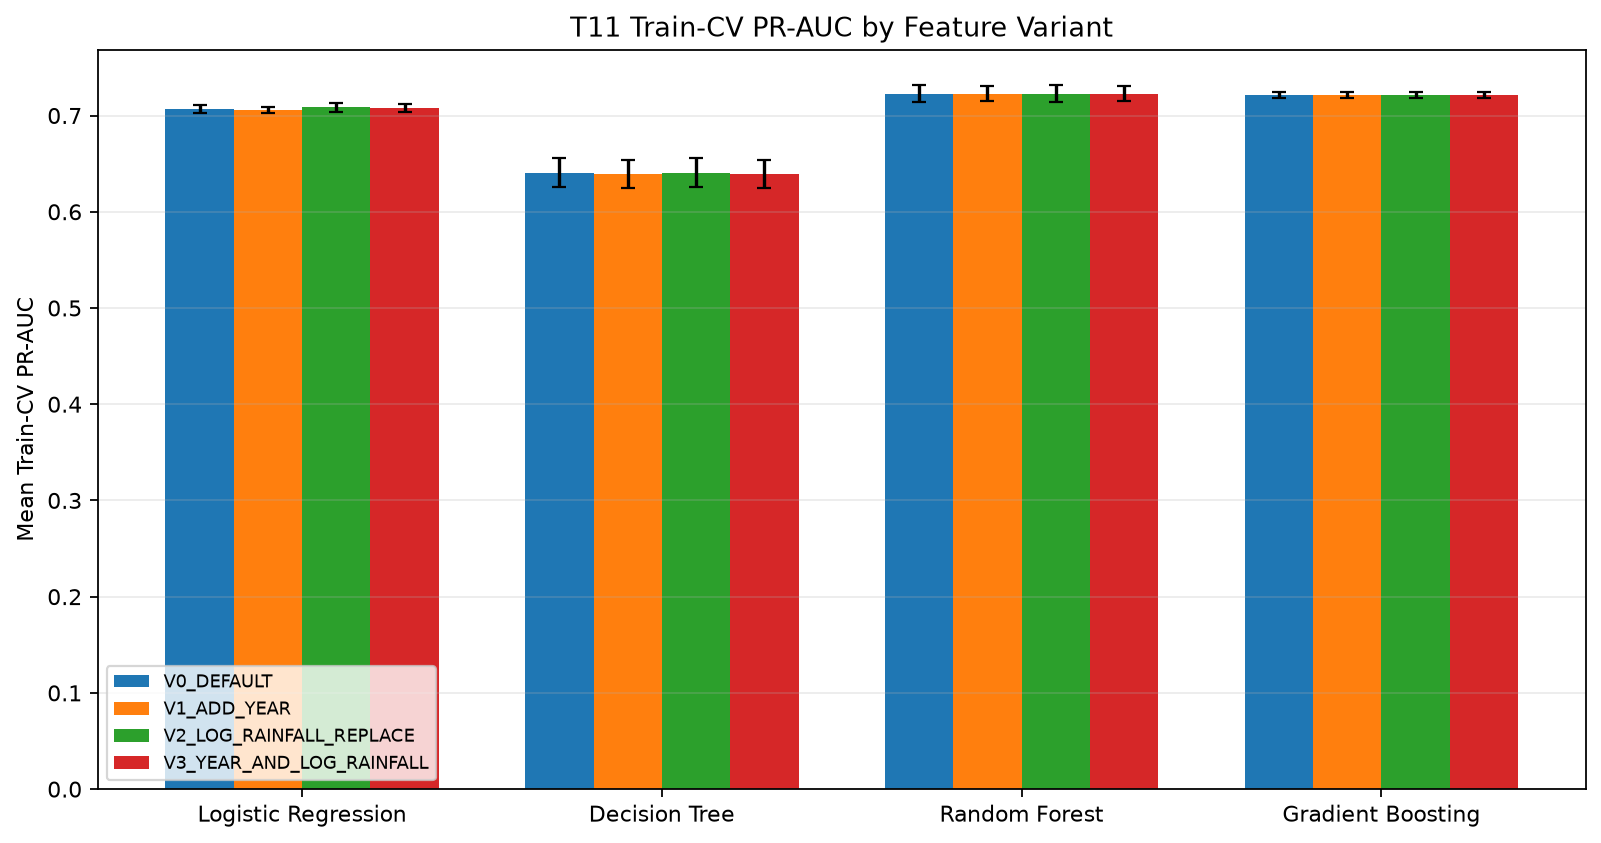

reports\figures\feature_optimization\11_t10_vs_t11_validation_metrics.png


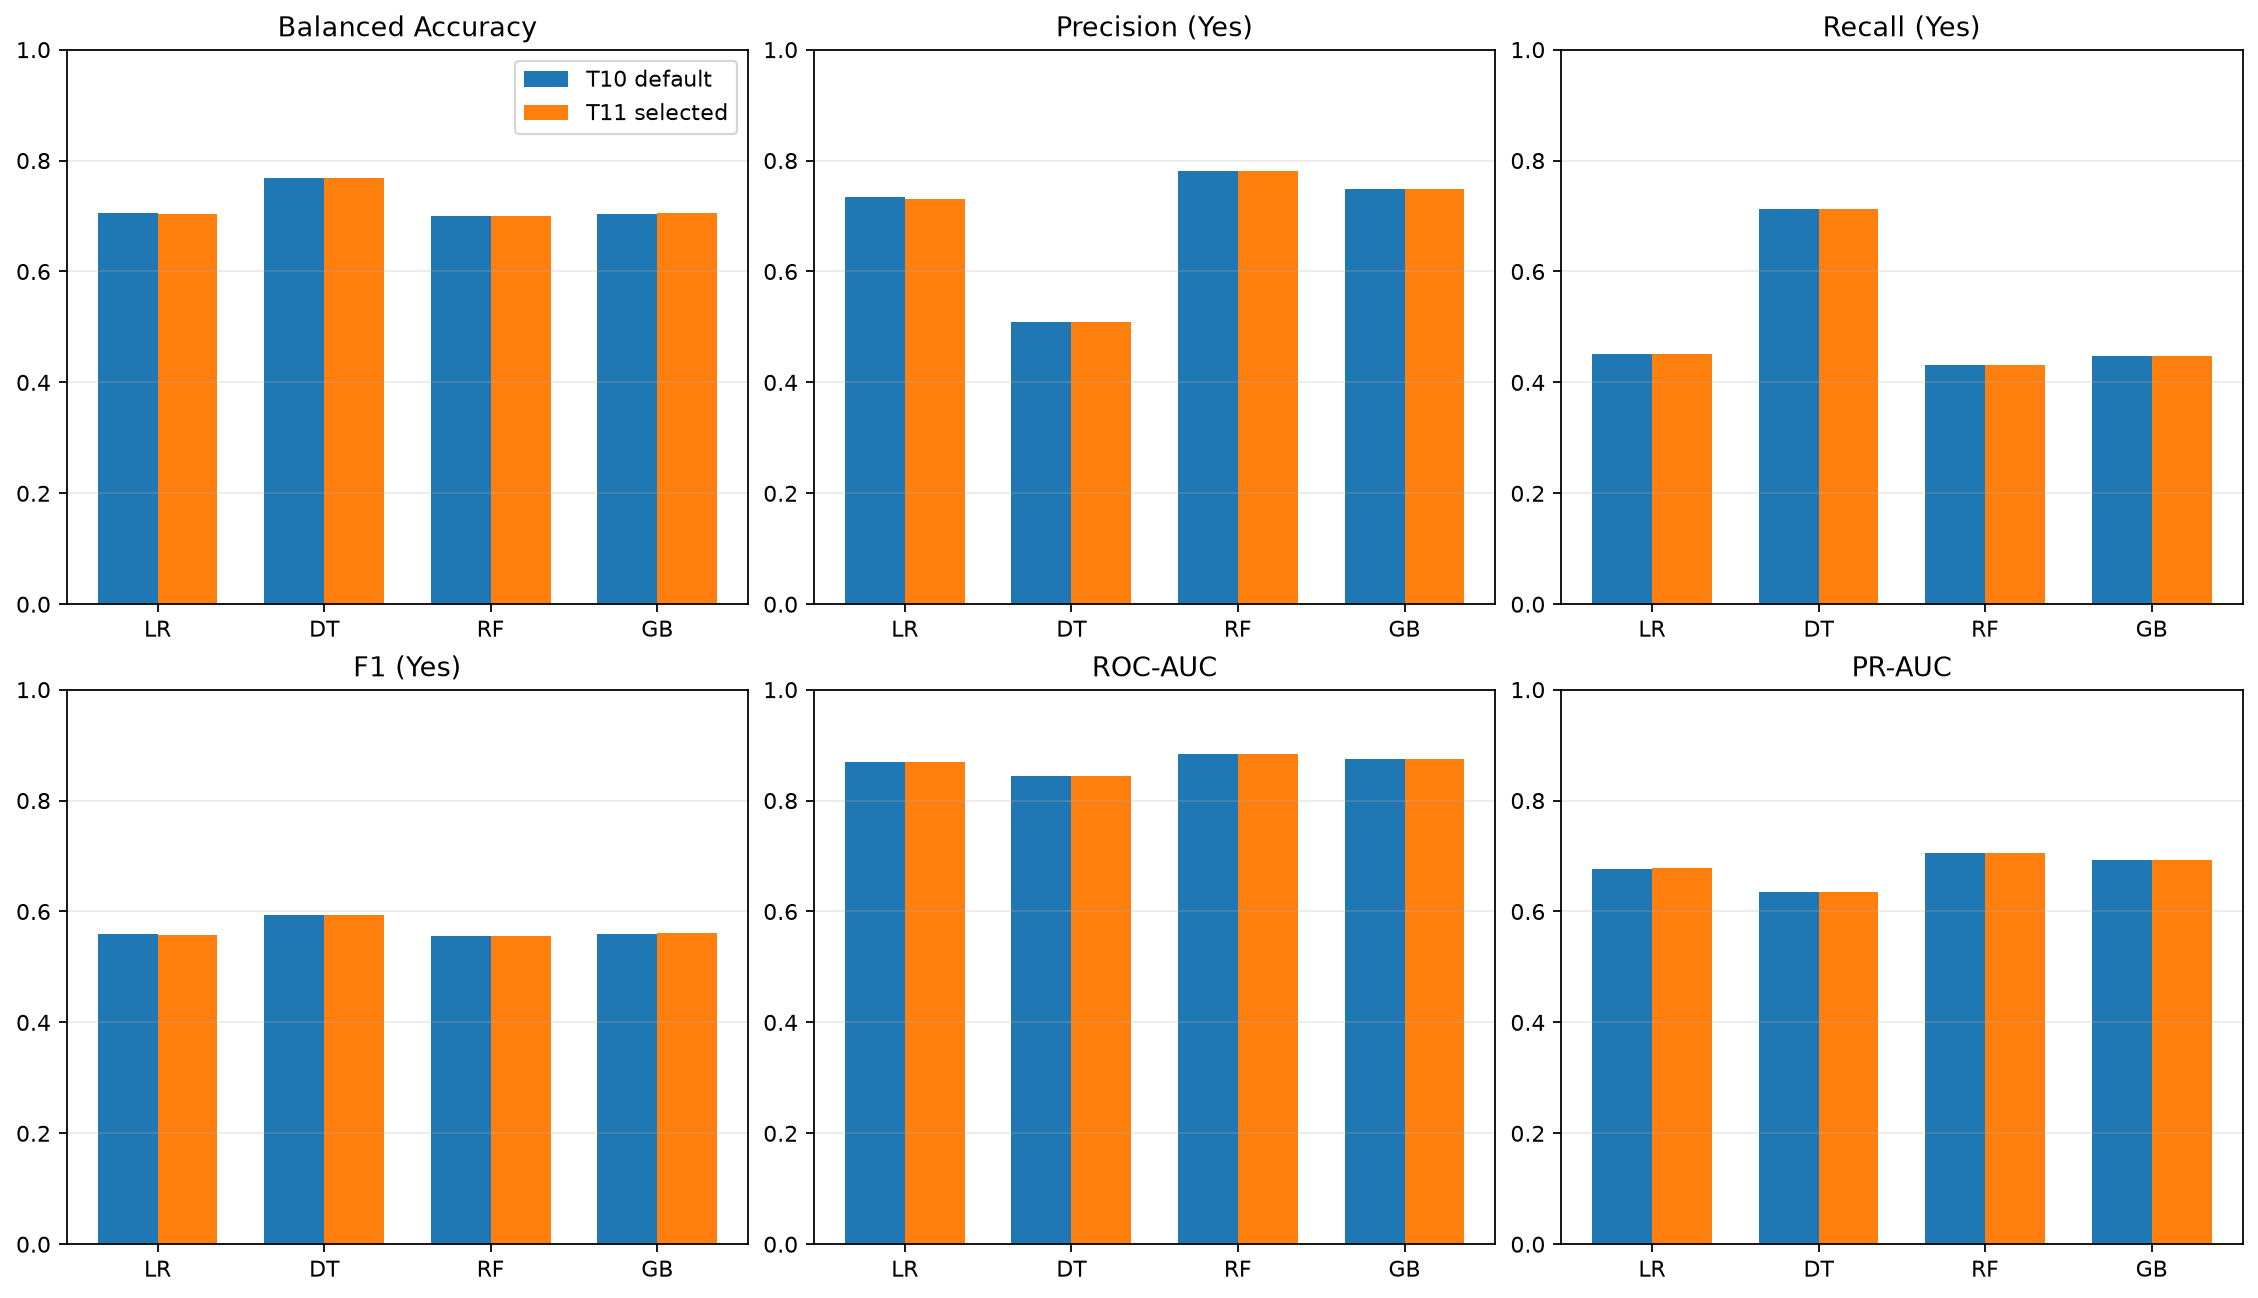

reports\figures\feature_optimization\11_validation_confusion_matrices.png


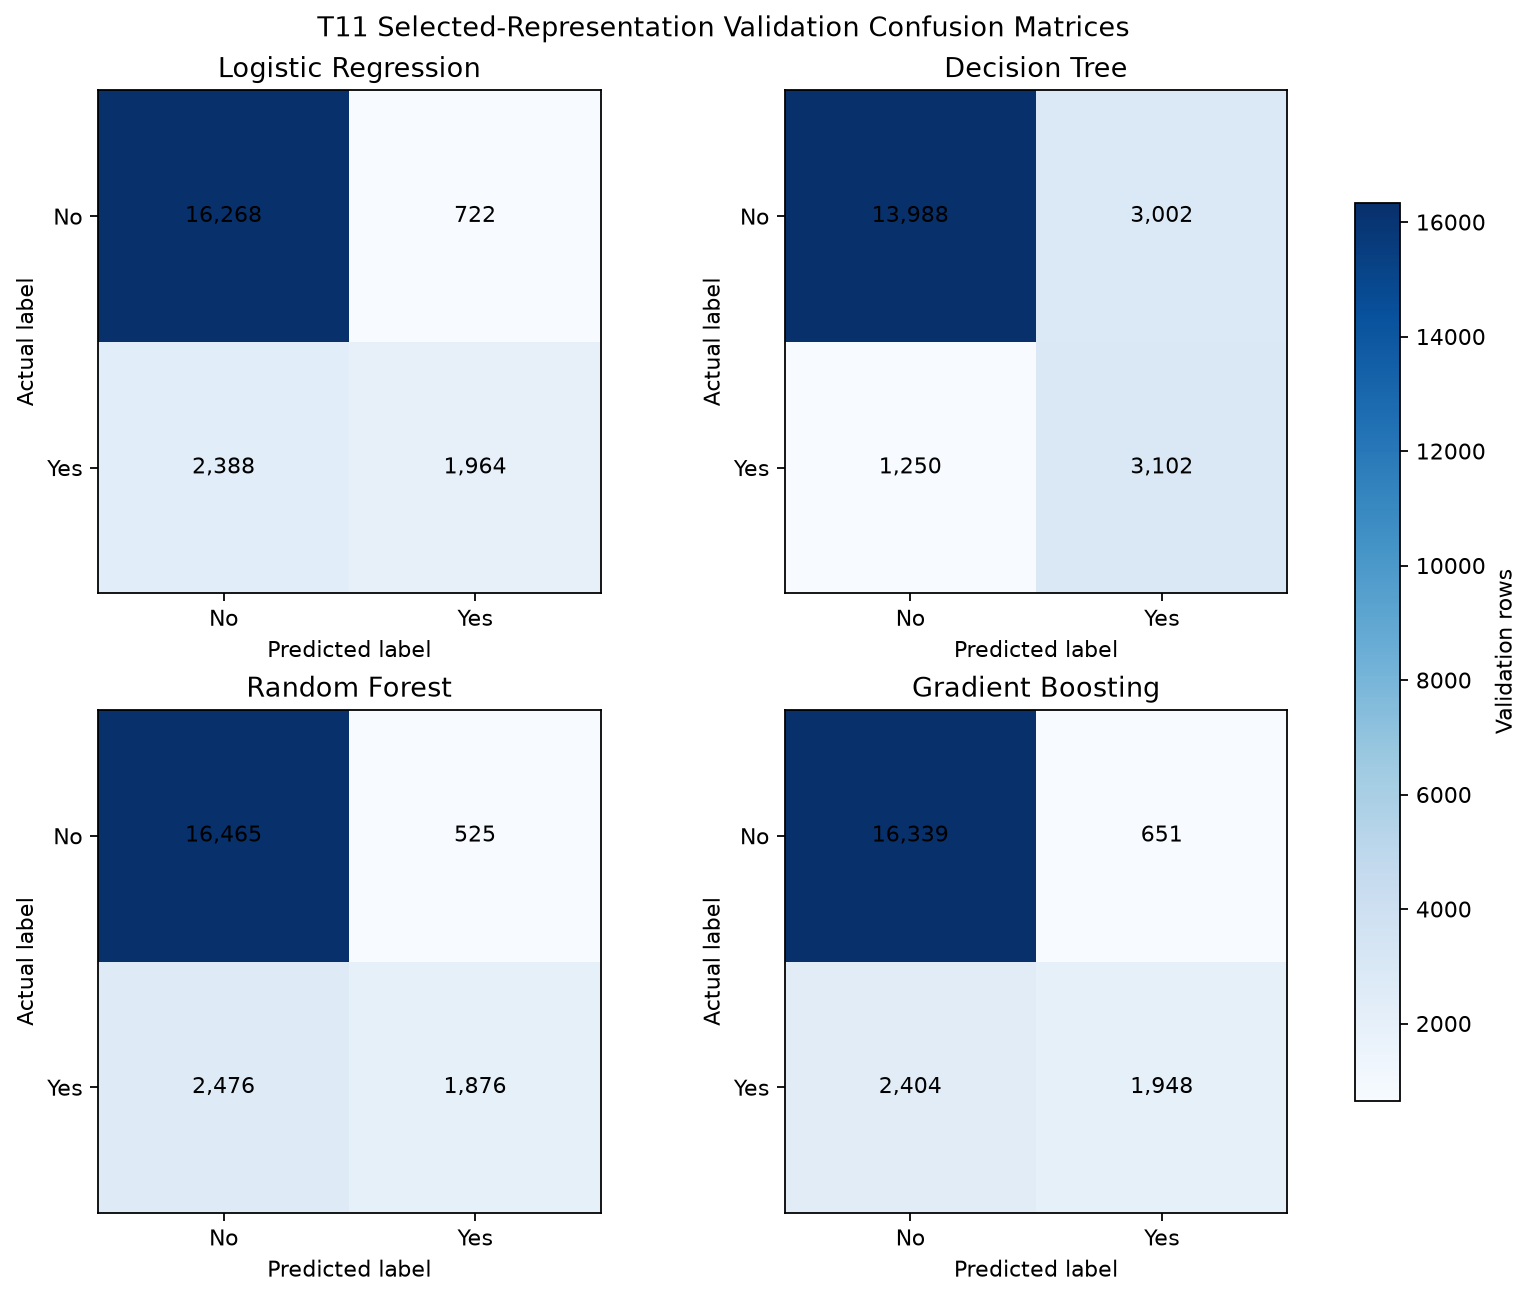

reports\figures\feature_optimization\11_validation_precision_recall_curves.png


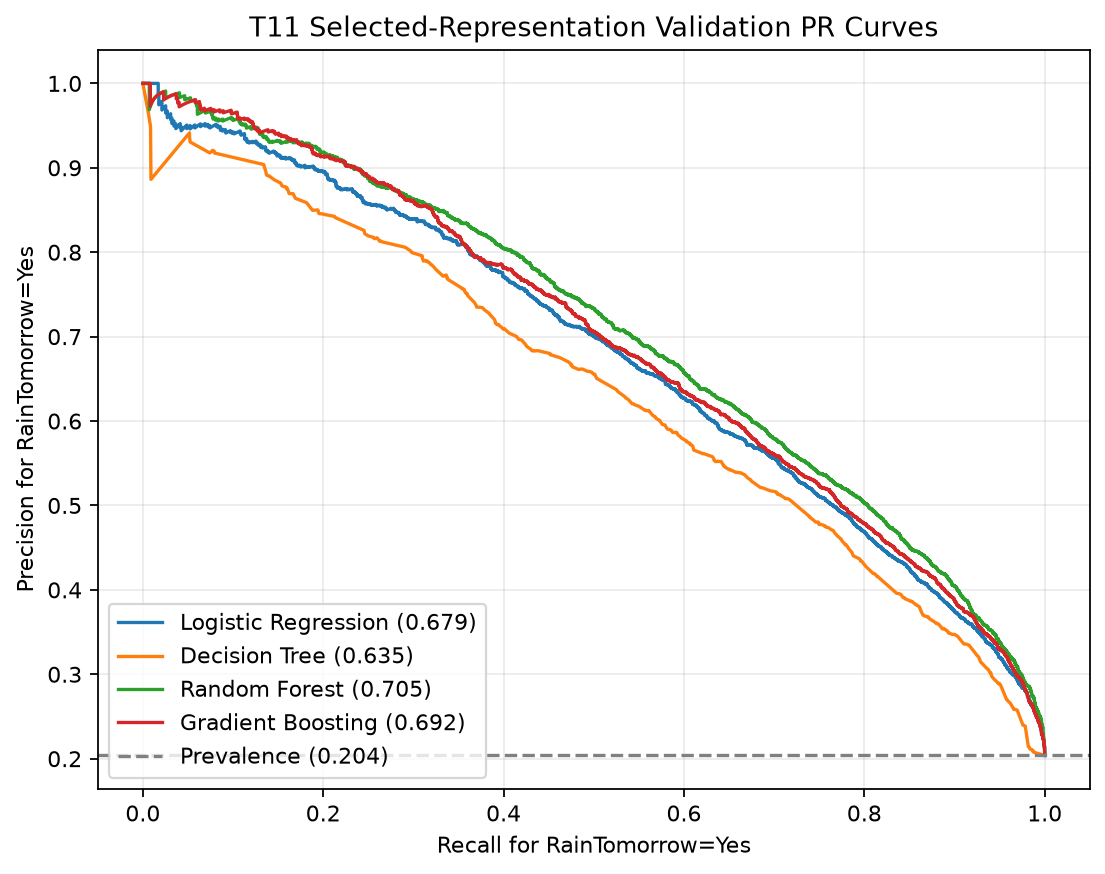

In [9]:
figure_paths = save_feature_optimization_figures(
    variant_summary, final, split.validation['RainTomorrow'], t10, FIGURE_DIR
)
for figure_path in figure_paths:
    print(figure_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(figure_path)))

## Runtime, interpretation, limitations, and T11 boundary

Year can capture temporal drift but may also encode dataset-period effects. `log1p` compresses Rainfall skewness, yet tree models need not benefit from a monotonic transformation. A lack of improvement is valid evidence and does not justify searching extra features after seeing results. Three Train folds cannot eliminate future distribution shift. T11 makes no final-model decision; T12 retains responsibility for final selection and one-time Test evaluation.

In [10]:
runtime_table = experiment.runtime_summary.copy()
runtime_table.loc[len(runtime_table)] = {
    'Model': 'ALL', 'Variant': 'Fold preprocessing', 'CV folds': 0,
    'Runtime seconds': preparation_seconds
}
runtime_table.loc[len(runtime_table)] = {
    'Model': 'ALL', 'Variant': 'Final fits and Validation predictions', 'CV folds': 0,
    'Runtime seconds': final.execution_times['Final fit and Validation prediction seconds'].sum()
}
runtime_table.loc[len(runtime_table)] = {
    'Model': 'ALL', 'Variant': 'Total recorded T11 experiment', 'CV folds': 48,
    'Runtime seconds': runtime_table['Runtime seconds'].sum()
}
runtime_table.to_csv(TABLE_DIR / '11_runtime_summary.csv', index=False)
display(runtime_table)
for _, row in winners.iterrows():
    print(f"{row['Model']}: {row['Selected feature variant']}; CV PR-AUC change vs V0 {row['Difference versus V0 default']:+.6f}")
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper() == EXPECTED_SHA256
print('T11 boundary confirmed: Test was not evaluated and no final model was selected.')

,Model,Variant,CV folds,Runtime seconds
0,Logistic Regression,V0_DEFAULT,3,1.656110
1,Logistic Regression,V1_ADD_YEAR,3,1.731328
2,Logistic Regression,V2_LOG_RAINFALL_REPLACE,3,1.588394
3,Logistic Regression,V3_YEAR_AND_LOG_RAINFALL,3,1.527298
4,Decision Tree,V0_DEFAULT,3,2.177688
5,Decision Tree,V1_ADD_YEAR,3,2.079544
6,Decision Tree,V2_LOG_RAINFALL_REPLACE,3,1.971088
7,Decision Tree,V3_YEAR_AND_LOG_RAINFALL,3,2.018738
8,Random Forest,V0_DEFAULT,3,5.591511
9,Random Forest,V1_ADD_YEAR,3,5.626544


Logistic Regression: V2_LOG_RAINFALL_REPLACE; CV PR-AUC change vs V0 +0.001510
Decision Tree: V0_DEFAULT; CV PR-AUC change vs V0 +0.000000
Random Forest: V0_DEFAULT; CV PR-AUC change vs V0 +0.000000
Gradient Boosting: V1_ADD_YEAR; CV PR-AUC change vs V0 +0.000224


T11 boundary confirmed: Test was not evaluated and no final model was selected.
